In [12]:
import pandas as pd
import numpy as np

print("1. Loading datasets safely...")
#data preprocessing
reviews = pd.read_csv('reviews.csv', dtype={'author_steamid': str, 'appid': str}, on_bad_lines='skip', engine='python')
apps = pd.read_csv('applications.csv', dtype={'appid': str}, low_memory=False)

print("2. Cleaning IDs to ensure a perfect merge...")
#stripping literal quotes and hidden spaces that hinder merges
reviews['appid'] = reviews['appid'].astype(str).str.strip().str.replace('"', '')
apps['appid'] = apps['appid'].astype(str).str.strip().str.replace('"', '')

#merging, and dropping empty rows
df = reviews.merge(apps[['appid', 'name']], on='appid', how='inner')
df = df.drop_duplicates(subset=['author_steamid', 'appid'])

print("3. Converting 'voted_up' to binary ratings...")
#forcing everything to a string,lowercase and remove quotes
df['voted_up_clean'] = df['voted_up'].astype(str).str.lower().str.strip().str.replace('"', '')
df['rating'] = df['voted_up_clean'].map({'true': 1, 'false': 0})

#dropping corrupted rows that didn't map successfully
df = df.dropna(subset=['rating', 'name'])
df['rating'] = df['rating'].astype(int)

print("4. Applying memory-saving filters...")
#filtering games (must have 50+ reviews)
min_game_reviews = 50
game_counts = df['name'].value_counts()
df = df[df['name'].isin(game_counts[game_counts >= min_game_reviews].index)]

#filtering users (must have reviewed 3+ games)
min_user_reviews = 3
user_counts = df['author_steamid'].value_counts()
df = df[df['author_steamid'].isin(user_counts[user_counts >= min_user_reviews].index)]

print(f"Final cleaned dataset: {len(df)} rows ready !!")



1. Loading datasets safely...
2. Cleaning IDs to ensure a perfect merge...
3. Converting 'voted_up' to binary ratings...
4. Applying memory-saving filters...
Final cleaned dataset: 58331 rows ready !!


**MATRIX FACTORIZATION USING SVD**

In [13]:
from scipy.sparse.linalg import svds

print("5. Building user-item matrix...")
user_item_matrix = df.pivot_table(index='author_steamid', columns='name', values='rating')

print("6. Centering ratings to handle user bias...")
avg_ratings = user_item_matrix.mean(axis=1)
user_ratings_centered = user_item_matrix.sub(avg_ratings, axis=0)
user_ratings_centered.fillna(0, inplace=True)

print("7. Running SVD Math...")
k_features = 20 #capturing 20 latent features like genres,playstyles,etc.
U, Sigma, Vt = svds(user_ratings_centered.to_numpy(), k=k_features)

#reversing the matrices (SVD returns them in ascending order)
Sigma = np.diag(Sigma[::-1])
U = U[:, ::-1]
Vt = Vt[::-1, :]

print("8. Reconstructing matrix for predictions...")
U_Sigma = np.dot(U, Sigma)
uncentered_ratings = np.dot(U_Sigma, Vt) + avg_ratings.values.reshape(-1, 1)

predicted_ratings_df = pd.DataFrame(
    np.round(uncentered_ratings, 2),
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print(" SVD Complete! 'predicted_ratings_df' is ready.")

5. Building user-item matrix...
6. Centering ratings to handle user bias...
7. Running SVD Math...
8. Reconstructing matrix for predictions...
 SVD Complete! 'predicted_ratings_df' is ready.


now to test the model

In [14]:
# grabbing a user who has reviewed a lot of games
import random

#finding users who have played a decent amount of games (at least 10)
user_counts = df['author_steamid'].value_counts()
eligible_users = user_counts[user_counts >= 10].index.tolist()

#picking 3 random users (we use a fixed seed so results don't randomly change again)
random.seed(42)
test_users = random.sample(eligible_users, 3)

print("TESTING SVD PERSONALIZATION ACROSS MULTIPLE USERS\n")


for user in test_users:
    print(f" USER ID: {user}")

    #games they actually played and liked
    user_history = df[(df['author_steamid'] == user) & (df['rating'] == 1)]['name'].tolist()

    #printing their first 5 played games to keep the output readable
    display_history = user_history[:5] + ["...and more"] if len(user_history) > 5 else user_history
    print(f"They play games like: {display_history}")

    #SVD predictions
    user_predictions = predicted_ratings_df.loc[user].sort_values(ascending=False)

    #filtering out what they already played
    recommendations = user_predictions[~user_predictions.index.isin(user_history)]

    print(f"Top 5 SVD Recommendations:")

    for rank, (game, score) in enumerate(recommendations.head(5).items(), 1):
        print(f"   {rank}. {game} (Score: {score:.2f})")
    print("=" * 60)


TESTING SVD PERSONALIZATION ACROSS MULTIPLE USERS

 USER ID: 76561198396392822
They play games like: ['Bloody Heaven 2', 'Abnormal1999:The Compass and the Sand', 'Dream Rhythm', 'Attack Core', 'Gas Giant Voyage', '...and more']
Top 5 SVD Recommendations:
   1. 🔴 Circles (Score: 1.00)
   2. ! That Bastard Is Trying To Steal Our Gold ! (Score: 1.00)
   3. ! Wild Russia ! (Score: 1.00)
   4. #SelfieTennis (Score: 1.00)
   5. (the) Gnorp Apologue (Score: 1.00)
 USER ID: 76561198863618909
They play games like: ['Gladiator Fights', 'Magical Runes', 'Cosmic Tempest', 'Bombunter', 'Runeblade Automaton', '...and more']
Top 5 SVD Recommendations:
   1. Play with my balls (Score: 1.04)
   2. Balls Gone Wild (Score: 1.02)
   3. Go Babies (Score: 0.99)
   4. F*ck the HELL out (Score: 0.98)
   5. Rap Pop Jump Core (Score: 0.98)
 USER ID: 76561199560128228
They play games like: ['Dungeon Survivors', 'Nuke Them All', 'King Lucas', 'F*ck the HELL out', 'Sus Virus Amogus', '...and more']
Top 5 SVD Recom

**NON PERSONALIZED RECOMMENDATIONS**

Wilson Scoring

In [16]:


print("TRENDING NOW: WILSON SCORING ")

#calculating Thumbs Up (rating=1) and Total Votes per game
game_stats = df.groupby('name').agg(
    thumbs_up_count=('rating', 'sum'),
    total_votes=('rating', 'count')
).reset_index()

#defining  Wilson Score Function
def wilson_score(up, n, z=1.96):
    if n == 0:
        return 0
    p = up / n
    return (p + z**2/(2*n) - z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / (1 + z**2/n)

#applying function to dataset
game_stats['wilson_score'] = game_stats.apply(
    lambda x: wilson_score(x['thumbs_up_count'], x['total_votes']), axis=1
)

#ranking and displaying Top 10
trending_games = game_stats.sort_values(by='wilson_score', ascending=False)
print("\nTop 10 trending games on Steam :")
print(trending_games[['name', 'wilson_score', 'thumbs_up_count', 'total_votes']].head(10))

TRENDING NOW: WILSON SCORING 

Top 10 trending games on Steam :
                            name  wilson_score  thumbs_up_count  total_votes
2266            MILFs in PARIS 💋      0.948670               71           71
3581               Steal The Pig      0.946527               68           68
4762   性感史莱姆派对（Slime Sexy Party）      0.944996               66           66
3335            Sex & Coffee ☕️🤎      0.940754               61           61
3399  Six-Ear Macaque: Awakening      0.932416               53           53
1868      I'm Truely a Good Guy!      0.931205               52           52
269                  Attack Core      0.929162               75           76
2801                 Path of Dao      0.929162               75           76
4518          We Are The Dwarves      0.927300               49           49
2588                  NeverSynth      0.925897               48           48


**Evaluation Metrics : Using Precision and Recall**

In [17]:
import random

print("1. Creating train/test split...")

#copying original cleaned dataframe
eval_df = df.copy()

#keeping only positive reviews (rating == 1) to use as "ground truth" ranking
positive_reviews = eval_df[eval_df['rating'] == 1]

#hiding 20% of positive reviews to use as test set
test_set = positive_reviews.sample(frac=0.20, random_state=42)

#remaining 80% --> training set
train_set = eval_df.drop(test_set.index)

print("2. Rebuilding matrix & running SVD on training data...")
#building the matrix using only training data
train_matrix = train_set.pivot_table(index='author_steamid', columns='name', values='rating').fillna(0)
train_avg = train_matrix.mean(axis=1)
train_centered = train_matrix.sub(train_avg, axis=0).fillna(0)

#running SVD
U_train, Sigma_train, Vt_train = svds(train_centered.to_numpy(), k=20)
Sigma_train = np.diag(Sigma_train[::-1])
U_train = U_train[:, ::-1]
Vt_train = Vt_train[::-1, :]

#getting predictions
pred_matrix = np.dot(np.dot(U_train, Sigma_train), Vt_train) + train_avg.values.reshape(-1, 1)

pred_df = pd.DataFrame(np.round(pred_matrix, 2), index=train_matrix.index, columns=train_matrix.columns)

#for top 5
print("3. Calculating Precision@5 and Recall@5...")
k = 5
precisions = []
recalls = []

#grouping hidden test games by user
test_users = test_set.groupby('author_steamid')['name'].apply(list).to_dict()

#evaluating each user
for user, hidden_games in test_users.items():
    if user in pred_df.index:
        #getting the top k recommendations for this user
        top_k_recs = pred_df.loc[user].sort_values(ascending=False).head(k).index.tolist()

        #how many of the hidden games were in the top k
        hits = len(set(top_k_recs).intersection(set(hidden_games)))

        precision = hits / k
        recall = hits / len(hidden_games)

        precisions.append(precision)
        recalls.append(recall)

#average precision and recall across all users
avg_precision = np.mean(precisions)
avg_recall = np.mean(recalls)

#calculating F1 score
f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)

print(f"Overall Precision@{k}: {avg_precision:.4f}")
print(f"Overall Recall@{k}:    {avg_recall:.4f}")
print(f"Overall F1-Score@{k}:  {f1_score:.4f}")


1. Creating train/test split...
2. Rebuilding matrix & running SVD on training data...
3. Calculating Precision@5 and Recall@5...
Overall Precision@5: 0.0203
Overall Recall@5:    0.0660
Overall F1-Score@5:  0.0311


Calculating metrics for different values of k...


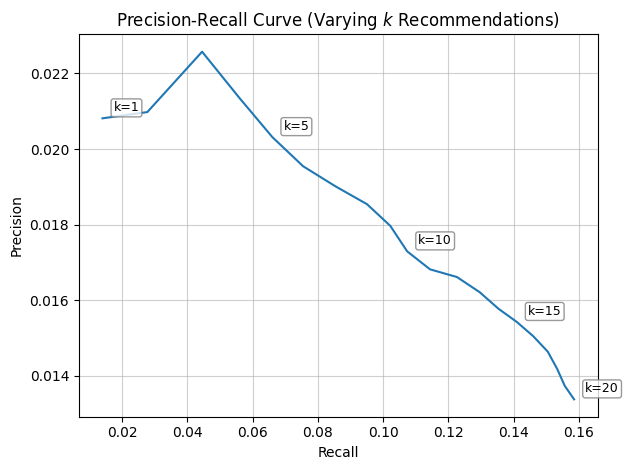

In [8]:
# PRECISION RECALL CURVE

import matplotlib.pyplot as plt

#defining the range of k values we want to plot (from 1 to 20 recommendations)
k_values = range(1, 21)
avg_precisions = []
avg_recalls = []

#looping through each k
for k in k_values:
    precisions = []
    recalls = []

    for user, hidden_games in test_users.items():
        if user in pred_df.index:
            #getting Top k recommendations
            top_k_recs = pred_df.loc[user].sort_values(ascending=False).head(k).index.tolist()

            hits = len(set(top_k_recs).intersection(set(hidden_games)))

            #appending scores
            precisions.append(hits / k)
            recalls.append(hits / len(hidden_games))

    avg_precisions.append(np.mean(precisions))
    avg_recalls.append(np.mean(recalls))

#plotting the Precision-Recall curve
plt.figure()
plt.plot(avg_recalls, avg_precisions)
plt.title('Precision-Recall Curve (Varying k Recommendations)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.6)

#annotating a few key 'k' values on the graph
for i, k in enumerate(k_values):
    if k in [1, 5, 10, 15, 20]:
        plt.annotate(f'k={k}',
                     (avg_recalls[i], avg_precisions[i]),
                     textcoords="offset points",
                     xytext=(8, 5),
                     ha='left',
                     fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="gray"))

plt.tight_layout()
plt.show()